In [5]:
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             RocCurveDisplay)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # imblearn NOT sklearn!

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


Saving creditcard.csv to creditcard.csv
Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


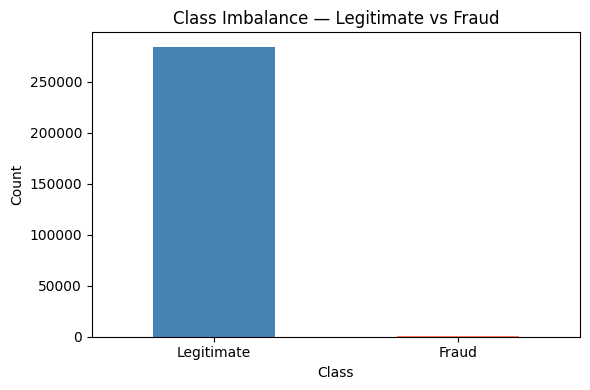

In [7]:
from google.colab import files
uploaded = files.upload()  # upload creditcard.csv

df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")

# Visualize imbalance
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar',
                                 color=['steelblue','coral'])
plt.title('Class Imbalance — Legitimate vs Fraud')
plt.xticks([0,1], ['Legitimate', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# STEP 1: Split FIRST — before any SMOTE!
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves fraud ratio in both sets
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"\nTraining fraud cases: {y_train.sum()}")
print(f"Testing fraud cases:  {y_test.sum()}")
print("\nSplit complete — SMOTE will only apply to training fold!")

Training set: (227845, 30)
Testing set:  (56962, 30)

Training fraud cases: 394
Testing fraud cases:  98

Split complete — SMOTE will only apply to training fold!


In [9]:
# Pipeline: StandardScaler → SMOTE → Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_params = {
    'smote__k_neighbors': [3, 5],
    'classifier__C': [0.01, 0.1, 1.0]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

print("Training Logistic Regression pipeline...")
lr_grid.fit(X_train, y_train)
print(f"Best params: {lr_grid.best_params_}")
print("Done!")

Training Logistic Regression pipeline...
Best params: {'classifier__C': 0.01, 'smote__k_neighbors': 3}
Done!


In [10]:
# Faster Random Forest Pipeline
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=100  # fixed, not tuned
    ))
])

# Smaller grid — only 2 combinations instead of 12
rf_params = {
    'smote__k_neighbors': [3, 5],
    'classifier__max_depth': [10, 20]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,          # 3 folds instead of 5
    scoring='recall',
    n_jobs=-1
)

print("Training Random Forest pipeline...")
rf_grid.fit(X_train, y_train)
print(f"Best params: {rf_grid.best_params_}")
print("Done!")

Training Random Forest pipeline...
Best params: {'classifier__max_depth': 10, 'smote__k_neighbors': 5}
Done!



  Logistic Regression
  Precision : 0.0591
  Recall    : 0.9184
  F1 Score  : 0.1110
  ROC-AUC   : 0.9719


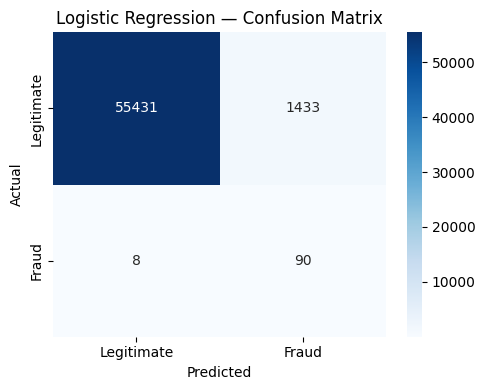


  Random Forest
  Precision : 0.5210
  Recall    : 0.8878
  F1 Score  : 0.6566
  ROC-AUC   : 0.9849


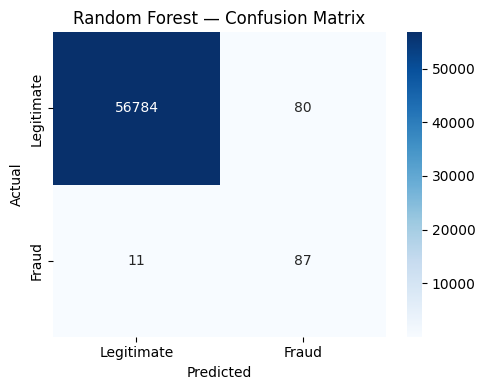

In [11]:
def evaluate_fraud_model(name, model, X_test, y_test):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"{'='*45}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate','Fraud'],
                yticklabels=['Legitimate','Fraud'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {
        'Precision': round(precision, 4),
        'Recall':    round(recall, 4),
        'F1':        round(f1, 4),
        'ROC-AUC':   round(roc_auc, 4)
    }

# Evaluate both
lr_results = evaluate_fraud_model(
    'Logistic Regression', lr_grid, X_test, y_test)

rf_results = evaluate_fraud_model(
    'Random Forest', rf_grid, X_test, y_test)

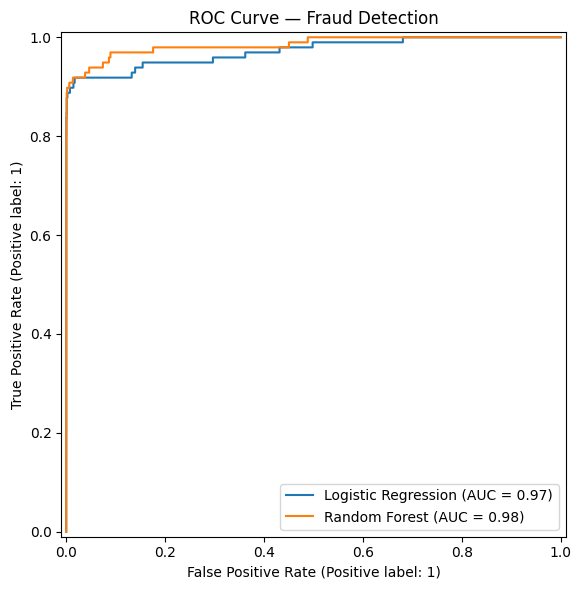


Final Comparison (NO Accuracy!):
                     Precision  Recall      F1  ROC-AUC
Logistic Regression     0.0591  0.9184  0.1110   0.9719
Random Forest           0.5210  0.8878  0.6566   0.9849


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved!


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    lr_grid, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(
    rf_grid, X_test, y_test, ax=ax, name='Random Forest')
ax.set_title('ROC Curve — Fraud Detection')
plt.tight_layout()
plt.show()

# Save comparison
results_df = pd.DataFrame({
    'Logistic Regression': lr_results,
    'Random Forest':       rf_results
}).T

print("\nFinal Comparison (NO Accuracy!):")
print(results_df)
results_df.to_csv('fraud_model_comparison.csv')

from google.colab import files
files.download('fraud_model_comparison.csv')
print("Saved!")

In [13]:
import pickle

# Save best model
with open('best_model_rf.pkl', 'wb') as f:
    pickle.dump(rf_grid, f)

from google.colab import files
files.download('best_model_rf.pkl')
files.download('fraud_model_comparison.csv')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
